In [2]:
import os
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
import jax.random as jr
from astropy.io import fits
from hmc_dust.better_hmc import HMCSampler
import jax.scipy.special as jss
import arviz as az
import blackjax
from jax.scipy.stats import t
from jax.scipy.special import logsumexp
from jax.scipy.special import gammaln
from jax.scipy.stats import norm

from hmc_dust import DATA, GAIA


from pathlib import Path

data_file = Path('../runs/overall_data_Gaia_XP_fitting_actual_data_M4_V16_38930858.npy')
tag = data_file.stem.removeprefix('overall_data_')
# -> 'Gaia_XP_fitting_actual_data_final_run'


INV_GAMMA_MEAN = 4
INV_GAMMA_VAR  = 16


overall_data_arr = jnp.asarray(np.load(data_file))
accept_prob_arr = jnp.zeros(overall_data_arr[0].size)


RUN = os.environ.get("SLURM_JOB_ID", "local")


def out(name):
    root, ext = os.path.splitext(name)
    return f"{root}_{RUN}{ext}"


fits_table = Table.read(GAIA / "gc_sightline.fits")


gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs


star_coords = SkyCoord(np.asarray(fits_table["ra"])*u.deg, np.asarray(fits_table["dec"])*u.deg)
fits_table["sep_gc_deg"] = star_coords.separation(gc_builtin).deg




plx_np = fits_table["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = fits_table["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = fits_table["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = fits_table["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = fits_table["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(fits_table.info())


with fits.open(DATA / "mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)


# 1000/x is its own inverse so this fcn is also plx_to_dist
def dist_to_plx(dist):
    return 1000/dist


def get_x_err_basic(plx_err, plx):
    return 1000*(plx**(-2))*plx_err


def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2)
    p_r = distance_logprior(r)
    return p_r + p_w_given_r


def get_x_err_advanced(plx_err, plx):
    x = jnp.linspace(0.1, 100000, 20000)
    log_posterior = logposterior_on_r(x, plx, plx_err)
    y = jnp.exp(log_posterior - jnp.max(log_posterior))
    Z    = jnp.trapezoid(y, x)                    
    mean = jnp.trapezoid(x * y, x) / Z
    var  = jnp.trapezoid((x - mean) ** 2 * y, x) / Z
    return jnp.sqrt(var)


def distance_logprior(r):
    return jnp.where(r > 0, -r/10000 + 2*jnp.log(r), -jnp.inf)








assert mean_along_center.shape == distance_gaps.shape
num_stars = plx.size
distances_psc = dist_to_plx(plx)


linspace = jnp.linspace(0.1, 20000, 500)
x_err_basic = jax.vmap(get_x_err_basic, in_axes=(None, 0))(0.1, 1000/linspace)
x_err_advanced = jax.vmap(get_x_err_advanced, in_axes=(None, 0))(0.1, 1000/linspace)

num_overall_steps = 250
burn_in = 50
num_dimensions = 600
num_fourier_dimensions = 1200
left_distance_padding = 40
right_distance_padding = 600
doing_burn_in = True
use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False


inv_gamma_variance_prior_alpha = INV_GAMMA_MEAN**2/INV_GAMMA_VAR + 2
inv_gamma_variance_prior_beta = INV_GAMMA_MEAN**3/INV_GAMMA_VAR + INV_GAMMA_MEAN
student_t_sigma = jnp.sqrt(inv_gamma_variance_prior_beta/inv_gamma_variance_prior_alpha)
student_t_nu = 2*inv_gamma_variance_prior_alpha


min_distance = radial_boundaries[0] - left_distance_padding
max_distance = radial_boundaries[radial_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
integrating_dims_padding_left = 20
integrating_dims_padding_right = 300
total_integrating_dims = integrating_dims_padding_left + integrating_dims_padding_right + num_dimensions
integrating_dust_x_linspace = jnp.arange(num_dimensions + integrating_dims_padding_left + integrating_dims_padding_right)*dx + min_distance - integrating_dims_padding_left*dx
# This is the analouge of fixed_points_linspace
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance

fourier_length = dx*(num_fourier_dimensions - 1)
num_fitting_params = 3
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
error_bars_on_data = 0.025


cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)])


x_obs = dist_to_plx(plx)
y_obs = ext




mask = (separation < 0.3) & (plx - plx_err > 1000/1800) & (plx + plx_err < 1000/40)
x_obs = x_obs[mask]
y_obs = y_obs[mask]
plx_obs = plx[mask]
data_ext_err = ext_err[mask]
data_plx_err = plx_err[mask]
x_error = jax.vmap(get_x_err_basic)(plx_err[mask], plx_obs)
num_data = x_obs.size
inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(ext_err[mask]**2))
inv_cov_plx_matrix = jnp.linalg.inv(jnp.diag(plx_err[mask]**2))


initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.6


logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset


normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
fixed_logscale = jnp.log(2*(max_distance - min_distance))
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)
num_integration_steps = 20000
initial_step_size = 0.00006
step_size = initial_step_size


def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2

def inv_gamma_logpdf(x, alpha, beta):
    # β^α / Γ(α) * x^(-α-1) * exp(-β/x),  x > 0
    return jnp.where(
        x > 0,
        alpha * jnp.log(beta) - gammaln(alpha) - (alpha + 1.0) * jnp.log(x) - beta / x,
        -jnp.inf,
    )

def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])

def average_chi_2_based_on_extinction(r, extinction, x_field, y_field, inverse_data_cov):
    def single(r_i, y_field_i):
        model_at_stars = jnp.interp(r_i, x_field, y_field_i)
        residual = extinction - model_at_stars
        return residual.T @ inverse_data_cov @ residual
    return jnp.average(jax.vmap(single, in_axes=(0, 0))(r, y_field))/extinction.size


def average_chi_2_based_on_r(r, plx_obs, inv_plx_cov):
    def single(r_i):
        residual = dist_to_plx(r_i) - plx_obs
        return residual.T @ inv_plx_cov @ residual
    return jnp.average(jax.vmap(single, in_axes = (0,))(r))/plx_obs.size

def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)


def response_function(xi, r, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(r, dust_x_linspace, exp_int_field)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:3 + num_fourier_dimensions]
    r = x[3 + num_fourier_dimensions:]
    # hardcoded r back to fixed values
    #r = x_obs_true
    inference_params = (logvar, lognu)
    # There are priors on everything: logvar, lognu, offset, xi, and r
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi - jnp.sum(distance_logprior(r))
    field_res = y_obs - response_function(xi, r, inference_params, offset)
    plx_res = plx_obs - dist_to_plx(r)


    field_t_scores = field_res/ext_err[mask]
    log_data_likelihoods = t.logpdf(field_t_scores, df = student_t_nu, loc = 0.0, scale = student_t_sigma)




    # P(all data given field, params, distance) is now the probability of observing the extinctions (first term) times the probabilty of observing the correct distances (second term)
    negative_log_p_d_given_s = -1*jnp.sum(log_data_likelihoods) + 0.5*plx_res.T @ inv_cov_plx_matrix @ plx_res
    return negative_log_p_s + negative_log_p_d_given_s


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]








<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None
Filename: /home/dtfrake/hmc-dust/Data_And_Samplers/mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST


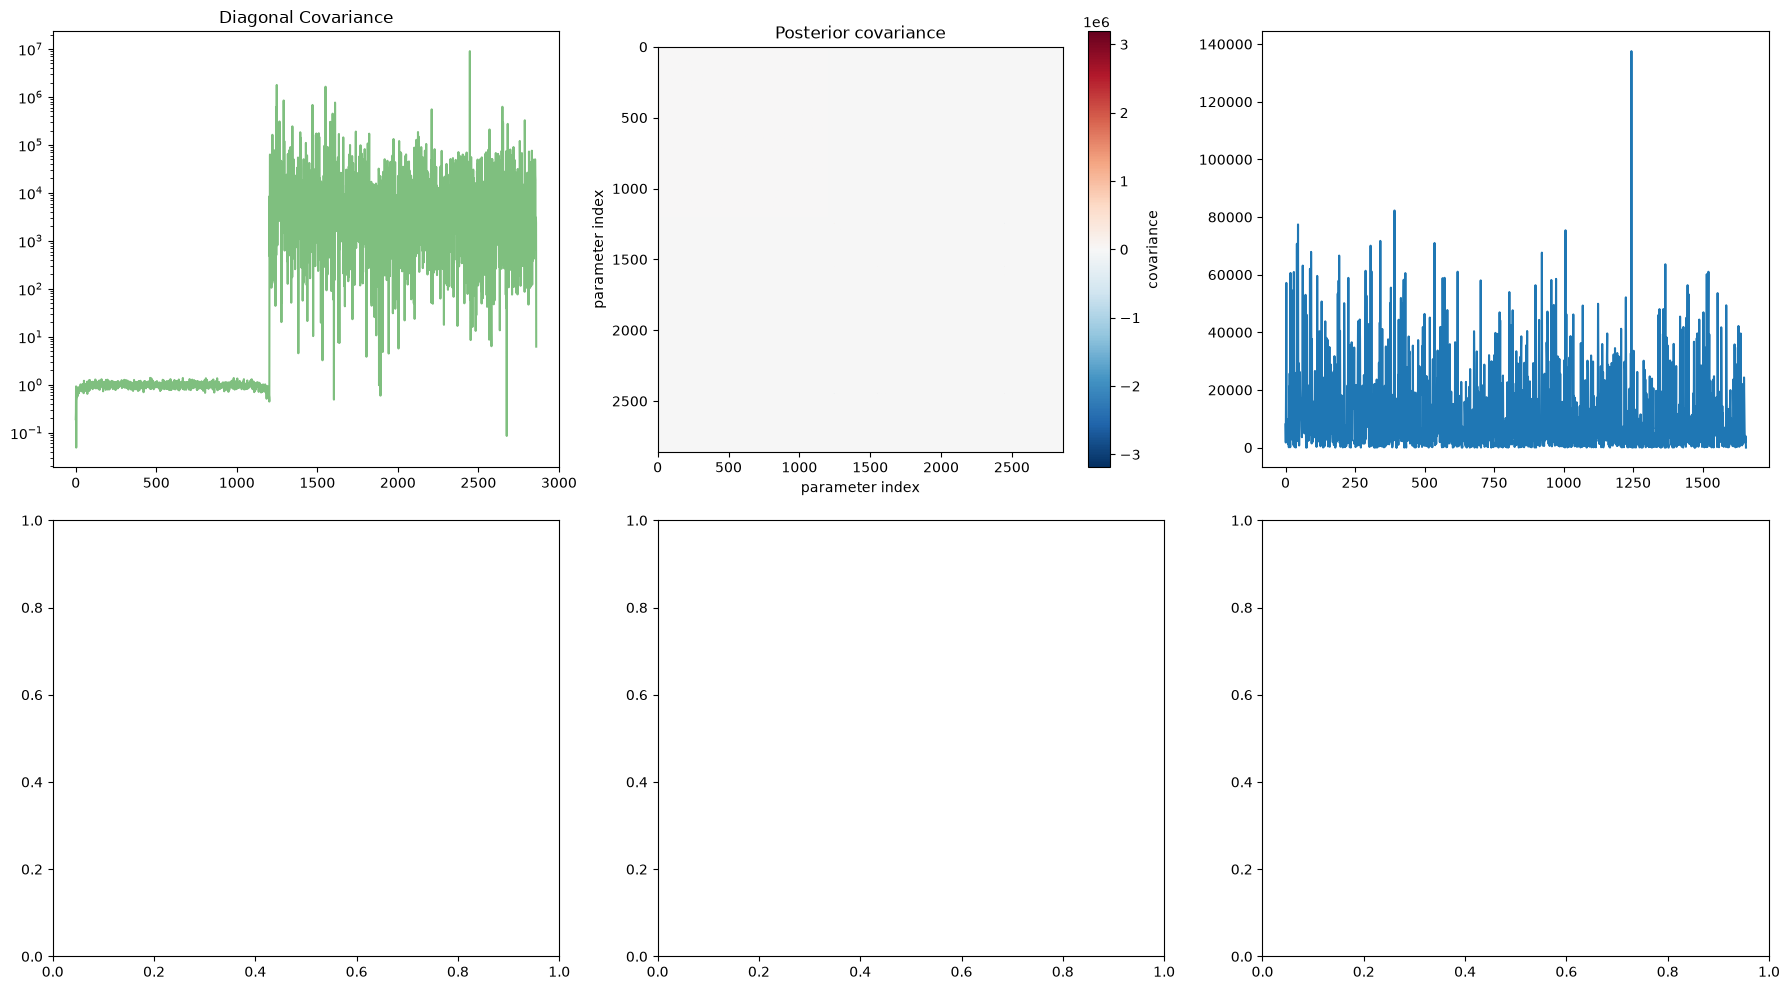

In [3]:
logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]  
overall_star_location_arr = overall_data_arr[:, 3 + num_fourier_dimensions:]

mean_star_location_arr = overall_star_location_arr.mean(axis=0)
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)


overall_extinction_arr_raw_before_offsets = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_extinction_arr, inference_params
)
overall_extinction_arr_raw = overall_extinction_arr_raw_before_offsets + offsets[:, None]
overall_extinction_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_extinction_arr_raw
)
overall_extinction_arr_raw = overall_extinction_arr_raw[:, 0:num_dimensions]
overall_extinction_arr_exp = overall_extinction_arr_exp[:, 0:num_dimensions]


mean_extinction_raw = overall_extinction_arr_raw.sum(axis=0)/num_good_samples
mean_extinction_exp = jnp.exp(overall_extinction_arr_raw).sum(axis = 0)/num_good_samples
log_mean_extinction_exp = jnp.log(mean_extinction_exp)
mean_extinction_exp_int = overall_extinction_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)


errorbar_linspace = jnp.arange(1000)*0.1 + 0.1
def exact_errorbar_loglike(errorbar_mul, ext_true, ext_obs, sigma):
    logprior = inv_gamma_logpdf(errorbar_mul, inv_gamma_variance_prior_alpha, inv_gamma_variance_prior_beta)
    log_p_ext_obs = norm.logpdf(ext_obs, loc=ext_true, scale=sigma * jnp.sqrt(errorbar_mul))
    return logprior + log_p_ext_obs

def average_errorbar_loglike(errorbar_mul, ext_true_arr, ext_obs, sigma):
    loglike_arr = jax.vmap(exact_errorbar_loglike, in_axes=(None, 0, None, None))(
        errorbar_mul, ext_true_arr, ext_obs, sigma
    )
    return logsumexp(loglike_arr) - jnp.log(ext_true_arr.shape[0])


def exact_position_loglike(index, plx_obs, plx_err, ext_obs, ext_err, field):
    # ext_true is the exponentiated integrated field
    r_exact = integrating_dust_x_linspace[index]
    n = field.shape[0]
    idx = jnp.clip(index - integrating_dims_padding_left, 0, n - 1)
    ext_true = field[idx]
    ext_t_score = (ext_obs - ext_true)/ext_err
    log_ext_likelihood = t.logpdf(ext_t_score, df = student_t_nu, loc = 0.0, scale = student_t_sigma)
    log_x_likelihood = distance_logprior(r_exact) - 0.5*((dist_to_plx(r_exact) - plx_obs)/plx_err)**2
    return log_ext_likelihood + log_x_likelihood




idx = jnp.clip(jnp.arange(total_integrating_dims) - integrating_dims_padding_left,
               0, num_dimensions - 1)
r_grid = integrating_dust_x_linspace[:total_integrating_dims]


# [P, S], sample-independent -- computed once
log_x = (distance_logprior(r_grid)[:, None]
         - 0.5 * ((dist_to_plx(r_grid)[:, None] - plx_obs[None, :]) / data_plx_err[None, :])**2)


@jax.jit
def accumulate(fields):                      # fields: [N_samples, num_dimensions]
    def body(acc, field):
        ext_true = field[idx]                                     # [P]
        tscore = (y_obs[None, :] - ext_true[:, None]) / data_ext_err[None, :]
        ll = t.logpdf(tscore, df=student_t_nu, loc=0.0, scale=student_t_sigma) + log_x
        return jnp.logaddexp(acc, ll), None
    init = jnp.full((total_integrating_dims, y_obs.size), -jnp.inf)
    log_sum, _ = jax.lax.scan(body, init, fields)
    return log_sum - jnp.log(fields.shape[0])


log_mean = accumulate(overall_extinction_arr_exp)




star_posterior_2d = jnp.exp(log_mean)          
dx = integrating_dust_x_linspace[1] - integrating_dust_x_linspace[0]
star_posterior_2d /= (star_posterior_2d.sum(axis=0, keepdims=True) * dx)


x = integrating_dust_x_linspace[:star_posterior_2d.shape[0]]
mean_star_location_arr_analytic = (x @ star_posterior_2d) / star_posterior_2d.sum(axis=0)   # [NUM_STARS]


cov= jnp.cov(overall_data_arr, rowvar = False)


fig, axes = plt.subplots(2, 3, figsize = (18, 10))
timegrid = jnp.arange(num_fourier_dimensions + num_fitting_params + num_data)
axes[0][0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
axes[0][0].set_title("Diagonal Covariance")
axes[0][0].set_yscale("log")
axes[0][2].plot(jnp.arange(data_plx_err.size), x_error**2)
C = np.asarray(cov)
off = C - np.diag(np.diag(C))
vmax = np.abs(off).max()         # symmetric limits so white = 0
im = axes[0][1].imshow(C, cmap='RdBu_r', vmin= -vmax, vmax=vmax)
fig.colorbar(im, ax=axes[0][1], label='covariance')
axes[0][1].set_title('Posterior covariance')
axes[0][1].set_xlabel('parameter index')
axes[0][1].set_ylabel('parameter index')




if use_NUTS or use_blackjax_hmc:
    step_size = parameters['step_size']
    inv_mass_matrix = parameters['inverse_mass_matrix']   # not 'inv_mass_matrix'
    if(window_adapt_square_mass_matrix):
        C = np.asarray(inv_mass_matrix)
        off = C - np.diag(np.diag(C))
        vmax = np.abs(off).max()        
        im = axes[1][0].imshow(jnp.log(C), cmap='RdBu_r', vmin= -vmax, vmax=vmax)
        axes[1][0].colorbar(im, ax=axes[0], label='covariance')
        axes[1][0].set_title('Posterior covariance')
        axes[1][0].set_xlabel('parameter index')
        axes[1][0].set_ylabel('parameter index')
        axes[1][1].plot(jnp.arange(jnp.diagonal(inv_mass_matrix)).size, inv_mass_matrix)
    else :
        axes[1][0].plot(jnp.arange(inv_mass_matrix.size), inv_mass_matrix)


fig.tight_layout()
fig.savefig(f'{tag}_cov_analysis.png', dpi=300, bbox_inches='tight')




In [4]:
def get_avg_errorbar_likelihoods(star_index):
    ext_obs_at_star = y_obs[star_index]
    ext_field_at_star_arr = jax.vmap(jnp.interp, in_axes=(0, None, 0))(
        overall_star_location_arr[:, star_index], dust_x_linspace, overall_extinction_arr_exp
    )
    avg_errorbar_loglikes = jax.vmap(average_errorbar_loglike, in_axes = (0, None, None, None))(errorbar_linspace, ext_field_at_star_arr, ext_obs_at_star, data_ext_err[star_index])
    avg_errorbar_likelihoods = jnp.exp(avg_errorbar_loglikes - jnp.max(avg_errorbar_loglikes))
    return avg_errorbar_likelihoods

def get_mean_errorbar_mul(star_index):
    avg_errorbar_likelihoods = get_avg_errorbar_likelihoods(star_index)
    return jnp.sum(avg_errorbar_likelihoods*errorbar_linspace)/jnp.sum(avg_errorbar_likelihoods)
mean_errorbars = jax.lax.map(
    get_mean_errorbar_mul,
    jnp.arange(x_obs.size),
    batch_size=20,          # tune this down if you still OOM
)

ESS for Variance parameter (index 0): 73.37390783372872
ESS for Nu parameter (index 1): 137.8475057402743
ESS for First mode:  parameter (index 3): 96.65001137425982
ESS for Second mode:  parameter (index 4): 99.6307410494025
ESS for 10th mode  parameter (index 12): 112.71541344712956
ESS for 100th mode parameter (index 102): 78.87059139969897
ESS for Last mode parameter (index 1202): 122.20472723816918
ESS for Star 0 parameter (index 1203): 43.55161973584541
ESS for Star 2 parameter (index 1205): 113.90198142416915
Use NUTS? False Use blackjax HMC? False Initial Step Size: 6e-05 Step Size: 6e-05 Num integration steps (only valid if no NUTS) 20000 Burn in: 50
Average acceptance probability (acceptance rate) is: 0.0
Num dimensions: 600 Num data: 1657 Total length: 1819.4813232421875 Noise on each point: 0.025 Num HMC trials: 250
Error bars on data: 0.025
Logvar prior mean: 4.0 Lognu prior mean: 0.0 Offset prior mean -7.6 Initial logvar/lognu/offset values: 4.0, 0, -7.6
Average chi_2 sta

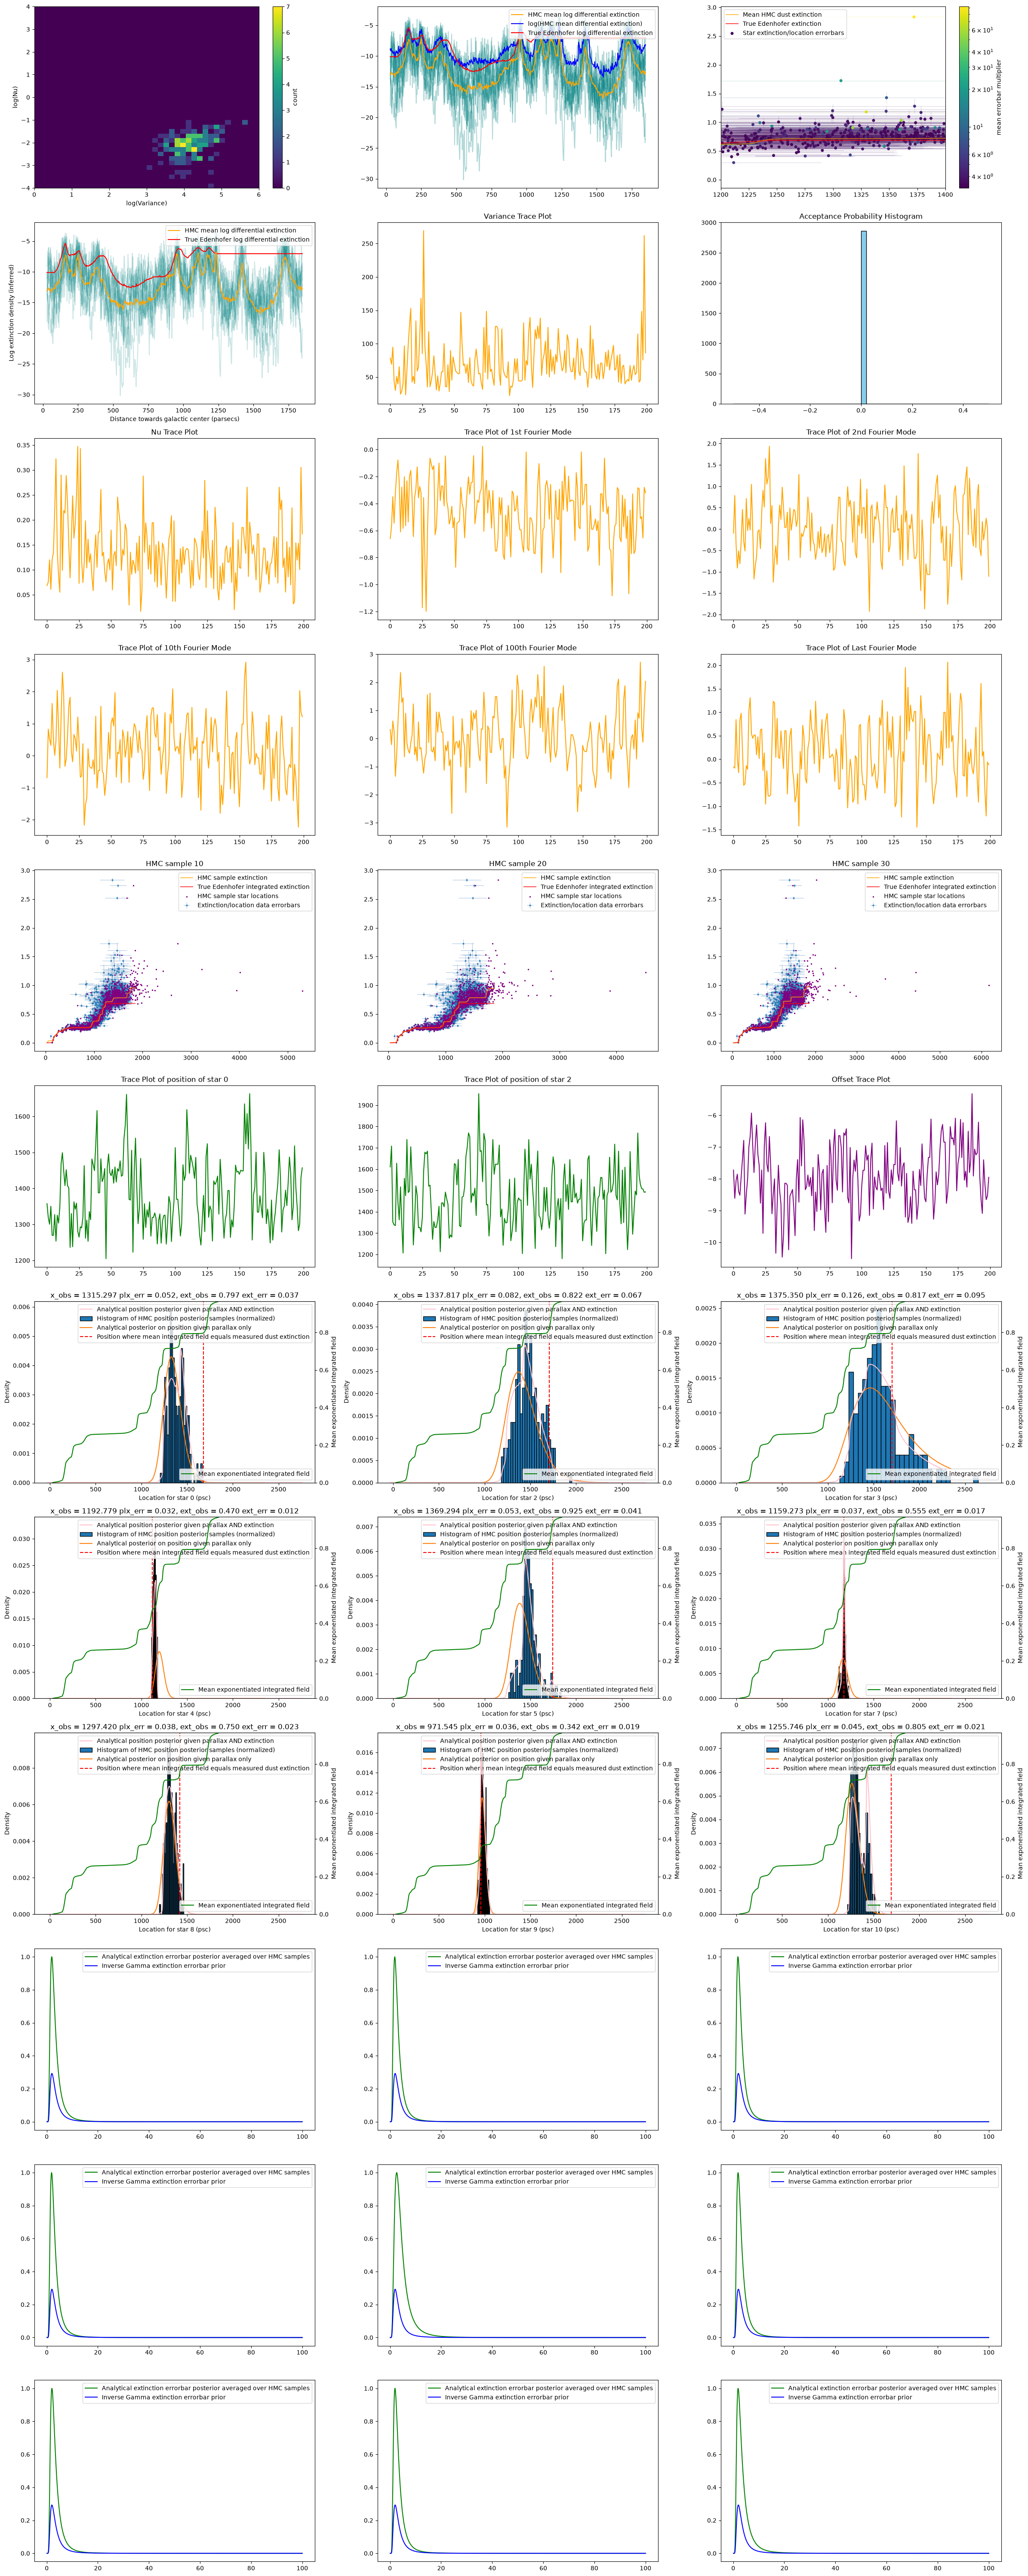

In [8]:
import matplotlib as mpl
from matplotlib.collections import LineCollection

fig, axes = plt.subplots(12, 3, figsize = (24, 60))
star_indices = jnp.arange(num_data)
star_mask = x_obs < 1400
star_indices = star_indices[star_mask]
samples_to_highlight = [10, 20, 30]


number_bins_x = 40
number_bins_y = 40
x_min, x_max = -0, 6
y_min, y_max = -4, 4
dx_plot = (x_max - x_min)/number_bins_x
dy_plot = (y_max - y_min)/number_bins_y


x_centers = (jnp.arange(number_bins_x) + 0.5)*dx_plot + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy_plot + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx_plot + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy_plot + y_min


H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])


im2 = axes[0][0].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][0], label='count')
axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")

for i in range (0, 10):
    axes[0][2].plot(dust_x_linspace, overall_extinction_arr_exp[20*i, :], color = "teal", alpha = 0.3)
    axes[0][1].plot(dust_x_linspace, overall_extinction_arr_raw[20*i, :], color = "teal", alpha = 0.3)


axes[0][1].plot(dust_x_linspace, mean_extinction_raw, color = "orange", alpha = 1, label = "HMC mean log differential extinction")
axes[0][1].plot(dust_x_linspace, log_mean_extinction_exp, color = "blue", alpha = 1, label = "log(HMC mean differential extinction)")
axes[0][1].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1, label = "True Edenhofer log differential extinction")
axes[0][1].legend(loc = "upper right")


axes[0][2].plot(dust_x_linspace, mean_extinction_exp_int, color = "orange", alpha = 0.7, zorder = 45, label = "Mean HMC dust extinction")
axes[0][2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 0.7, zorder = 50, label = "True Edenhofer extinction")



########################### Claude-Generated color-mapping code BEGINS HERE
ax = axes[0][2]
x = np.asarray(x_obs, dtype=float)
y = np.asarray(y_obs, dtype=float)
c = np.asarray(mean_errorbars, dtype=float)   # jax -> numpy
n_all = x.size

START, END  = 1200, 1400                        # <-- selection interval
FILTER_AXIS = 'x'                              # 'x' or 'y'
ERR_ALPHA   = 0.2                              # faint bars
PT_ALPHA    = 1.0                              # solid markers

def _lohi(e, n):
    """(low, high) length-n arrays from a scalar, (n,), or (2, n) error spec."""
    if e is None:
        return None, None
    e = np.asarray(e, dtype=float)
    if e.ndim == 2:                            # asymmetric, shape (2, n)
        return e[0], e[1]
    e = np.broadcast_to(e, (n,))
    return e, e

# broadcast error specs to full length FIRST, so masking keeps them aligned
y_lo, y_hi = _lohi(data_ext_err, n_all)          # vertical bars
x_lo, x_hi = _lohi(x_error, n_all)               # horizontal bars

# --- select on marker position only; bars may extend outside [START, END]
pos  = x if FILTER_AXIS == 'x' else y
keep = (pos >= START) & (pos <= END)
x, y, c = x[keep], y[keep], c[keep]
if y_lo is not None:
    y_lo, y_hi = y_lo[keep], y_hi[keep]
if x_lo is not None:
    x_lo, x_hi = x_lo[keep], x_hi[keep]
n = x.size

positive = c[np.isfinite(c) & (c > 0)]
if n == 0 or positive.size == 0:
    raise ValueError(f"no stars with positive c in {FILTER_AXIS} "
                     f"interval ({START}, {END})")

# --- draw order: low c first, high c (lighter) last so it lands on top.
# non-finite / non-positive values are masked by LogNorm and rendered as
# set_bad, so push them to the very bottom instead of letting argsort
# park the NaNs at the end (i.e. on top).
sort_key = np.where(np.isfinite(c) & (c > 0), c, -np.inf)
order = np.argsort(sort_key, kind='stable')

cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('lightgrey')                      # applies to scatter + bars too
# color scale spans only the shown stars; use the unmasked c for a fixed
# scale shared across panels
impostor_norm = mpl.colors.LogNorm(vmin=positive.min(), vmax=positive.max())

xs, ys, cs = x[order], y[order], c[order]
colors = cmap(impostor_norm(cs))
if y_lo is not None:
    y_lo, y_hi = y_lo[order], y_hi[order]
if x_lo is not None:
    x_lo, x_hi = x_lo[order], x_hi[order]

# interleave per point, so a whole point's cross is painted before the next
segs, seg_colors = [], []
for i in range(n):
    if y_lo is not None:
        segs.append([(xs[i], ys[i] - y_lo[i]), (xs[i], ys[i] + y_hi[i])])
        seg_colors.append(colors[i])
    if x_lo is not None:
        segs.append([(xs[i] - x_lo[i], ys[i]), (xs[i] + x_hi[i], ys[i])])
        seg_colors.append(colors[i])

if segs:
    ax.add_collection(LineCollection(segs, colors=np.asarray(seg_colors),
                                     linewidths=0.8, alpha=ERR_ALPHA,
                                     capstyle='butt', zorder=2))

ax.scatter(xs, ys, c=cs, cmap=cmap, norm=impostor_norm, s=4**2, alpha=PT_ALPHA,
           zorder=3, label="Star extinction/location errorbars")
ax.autoscale_view()

cb = fig.colorbar(mpl.cm.ScalarMappable(norm=impostor_norm, cmap=cmap), ax=ax)
cb.set_label("mean errorbar multiplier")
#################################  Claude-Generated color-mapping code ENDS HERE




#axes[0][2].scatter(mean_star_location_arr, y_obs, color = "purple", s = 2, zorder = 10, label = "Mean HMC star locations")
axes[0][2].set_xlim(START, END)
axes[0][2].legend(loc = "upper left")


axes[1][0].set_ylabel("Log extinction density (inferred)")
axes[1][0].set_xlabel("Distance towards galactic center (parsecs)")
axes[1][0].plot(dust_x_linspace, mean_extinction_raw, color = "orange", alpha = 1, zorder = 10, label = "HMC mean log differential extinction")

indices_plot_10 = np.array([20*i for i in range(10)])
for k, i in enumerate(range(indices_plot_10.size)):
    axes[1][0].plot(dust_x_linspace, overall_extinction_arr_raw[indices_plot_10[i], :], color = "teal", alpha=0.2,)


axes[1][0].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1, label = "True Edenhofer log differential extinction")
axes[1][0].legend(loc = "upper right")


axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")


axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')


axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")


axes[2][1].plot(time_arr, overall_extinction_arr[:, 0], color = "Orange")
axes[2][1].set_title("Trace Plot of 1st Fourier Mode")


axes[2][2].plot(time_arr, overall_extinction_arr[:, 1], color = "Orange")
axes[2][2].set_title("Trace Plot of 2nd Fourier Mode")

axes[3][0].plot(time_arr, overall_extinction_arr[:, 9], color = "Orange")
axes[3][0].set_title("Trace Plot of 10th Fourier Mode")

axes[3][1].plot(time_arr, overall_extinction_arr[:, 99], color = "Orange")
axes[3][1].set_title("Trace Plot of 100th Fourier Mode")


axes[3][2].plot(time_arr, overall_extinction_arr[:, num_fourier_dimensions - 1], color = "Orange")
axes[3][2].set_title("Trace Plot of Last Fourier Mode")



for i in range (0, 3):
    axes[4][i].plot(dust_x_linspace, overall_extinction_arr_exp[samples_to_highlight[i], :], color = 'orange', alpha = 0.7, zorder = 10, label = "HMC sample extinction")
    axes[4][i].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 0.7, zorder = 20, label = "True Edenhofer integrated extinction")
    axes[4][i].errorbar(x_obs, y_obs, yerr = data_ext_err, xerr = x_error, fmt='.', markersize=4, ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8, zorder = 1, label = "Extinction/location data errorbars")
    axes[4][i].scatter(overall_star_location_arr[samples_to_highlight[i], :], y_obs, color = "purple", s = 2, zorder = 3, label = "HMC sample star locations")
    axes[4][i].set_title(f"HMC sample {samples_to_highlight[i]}")
    axes[4][i].legend(loc = "upper right")
    max_v = float(jnp.max(mean_extinction_exp_int))
    for j in range (0, 3):
        ax = axes[6 + j][i]
        lower_ax = axes[9 + j][i]
        star_index = star_indices[i + 3*j]
        avg_errorbar_likelihoods = get_avg_errorbar_likelihoods(star_index)
        prior_loglikes = inv_gamma_logpdf(errorbar_linspace, inv_gamma_variance_prior_alpha, inv_gamma_variance_prior_beta)
        prior_loglikes = jnp.exp(prior_loglikes)
        lower_ax.plot(errorbar_linspace, avg_errorbar_likelihoods, color = "green", label = "Analytical extinction errorbar posterior averaged over HMC samples")
        lower_ax.plot(errorbar_linspace, prior_loglikes, color = "blue", label = "Inverse Gamma extinction errorbar prior")
        lower_ax.legend(loc = "upper right")

        ax.plot(integrating_dust_x_linspace, star_posterior_2d[:, star_index], color = "pink", zorder = 100, label = "Analytical position posterior given parallax AND extinction")
        ax.hist(overall_star_location_arr[:, star_index], bins=30, edgecolor="black", density=True, label="Histogram of HMC position posterior samples (normalized)")
        ax.set_xlabel(f"Location for star {star_index} (psc)")
        ax.set_ylabel("Density")
        star_linspace = jnp.linspace(min_distance, max_distance + 500, num_dimensions)
        log_r_posterior = logposterior_on_r(star_linspace, plx_obs[star_indices[i + 3*j]], data_plx_err[star_index])
        r_posterior = jnp.exp(log_r_posterior - jnp.max(log_r_posterior))
        r_posterior = (r_posterior/jnp.sum(r_posterior))*num_dimensions/(max_distance + 500 - min_distance)
        ax.plot(star_linspace, r_posterior, label="Analytical posterior on position given parallax only")
        ax.axvline(x=jnp.interp(y_obs[star_indices[i + 3*j]], mean_extinction_exp_int, dust_x_linspace),
                   color="red", linestyle="--",
                   label="Position where mean integrated field equals measured dust extinction")
        ax.set_title(f"x_obs = {x_obs[star_index]:.3f} plx_err = {data_plx_err[star_index]:.3f}, ext_obs = {y_obs[star_index]:.3f} ext_err = {data_ext_err[star_index]:.3f}")


        ax2 = ax.twinx()
        ax2.plot(dust_x_linspace, mean_extinction_exp_int, color="green",
                 label="Mean exponentiated integrated field")
        ax2.set_ylim(0, max_v)                          # identical across all nine plots
        ax2.set_ylabel("Mean exponentiated integrated field")
        ax.legend(loc = "upper right")
        ax2.legend(loc = "lower right")


axes[5][0].plot(time_arr, overall_star_location_arr[:, star_indices[0]], color = "Green")
axes[5][0].set_title(f"Trace Plot of position of star {star_indices[0]}")


axes[5][1].plot(time_arr, overall_star_location_arr[:, star_indices[1]], color = "Green")
axes[5][1].set_title(f"Trace Plot of position of star {star_indices[1]}")


axes[5][2].plot(time_arr, offsets, color = "Purple")
axes[5][2].set_title("Offset Trace Plot")


fig.tight_layout()

fig.savefig(f'{tag}_plots_analysis.png', dpi=100)

posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)
idata = az.from_dict({"posterior": {"theta": posterior_samples}})
ess_param_index = 30  
az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [ess_param_index]})


ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once
indices_of_interest = {"Variance": 0, "Nu": 1, "First mode: ": num_fitting_params, "Second mode: ": num_fitting_params + 1, "10th mode ": num_fitting_params + 9, "100th mode": num_fitting_params + 99, 
                       "Last mode": num_fourier_dimensions + num_fitting_params - 1,  f"Star {star_indices[0]}": star_indices[0] + num_fitting_params + num_fourier_dimensions, f"Star {star_indices[1]}": star_indices[1] + num_fitting_params + num_fourier_dimensions}
for label, idx in indices_of_interest.items():
    ess_val = ess_all["theta"].sel(theta_dim_0=idx).values
    print(f"ESS for {label} parameter (index {idx}): {ess_val}")


print(f"Use NUTS? {use_NUTS} Use blackjax HMC? {use_blackjax_hmc} Initial Step Size: {initial_step_size} Step Size: {step_size} Num integration steps (only valid if no NUTS) {num_integration_steps} Burn in: {burn_in}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {max_distance - min_distance} Noise on each point: {error_bars_on_data} Num HMC trials: {num_overall_steps}")
prior_variances = jnp.diag(cov)[3:3 + num_fourier_dimensions]
print(f"Error bars on data: {error_bars_on_data}")
print(f"Logvar prior mean: {logvar_prior_mean} Lognu prior mean: {lognu_prior_mean} Offset prior mean {offset_prior_mean} Initial logvar/lognu/offset values: {initial_logvar}, {initial_lognu}, {initial_offset}")
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")  
print(f"Average chi_2 statistic based on the extinction per star: {average_chi_2_based_on_extinction(overall_star_location_arr, y_obs, dust_x_linspace, overall_extinction_arr_exp, inv_cov_data_matrix)}")
print(f"Average chi_2 statistic based on the distance/parallax per star: {average_chi_2_based_on_r(overall_star_location_arr, plx_obs, inv_cov_plx_matrix)}")

plt.close()
